# Stock Performance Analysis Tool
## ACC102 Mini Assignment - Track 4: Interactive Data Analysis Tool

---

### 1. Problem Definition and Target User

**Analytical Problem:** 
Individual investors often struggle to compare stock performance across different companies and sectors. This tool aims to provide a comprehensive analysis of stock performance metrics, helping users make informed investment decisions.

**Target User:** 
- Individual investors seeking quick stock performance comparison
- Finance students learning about stock analysis
- Small business owners considering stock investments

**Business Relevance:** 
Stock market analysis is crucial for investment decision-making. Understanding price trends, volatility, and comparative performance helps investors optimize their portfolios and manage risk effectively.

### 2. Data Loading and Preparation

In [18]:
!pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------- -------------- 1.0/1.7 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 5.7 MB/s  0:00:00

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ------------------------ --------------- 3/5 [curl_cffi]
   ------------------------ --------------- 3/5 [curl_cffi]
   ------------------------ --------------- 3/5 [curl_c

In [2]:
# Import required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Configure plot style
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Create output directories
os.makedirs('data', exist_ok=True)
os.makedirs('figures', exist_ok=True)

print("Libraries imported successfully!")

Libraries imported successfully!


#### 2.1 Define Stock Universe

We will analyze a selection of major US stocks from different sectors to provide diversified insights:
- **Technology:** Apple (AAPL), Microsoft (MSFT)
- **Finance:** JPMorgan Chase (JPM), Bank of America (BAC)
- **Consumer:** Coca-Cola (KO), Walmart (WMT)
- **Healthcare:** Johnson & Johnson (JNJ)

In [8]:
# Define stock tickers and company names
STOCKS = {
    'AAPL': 'Apple Inc.',
    'MSFT': 'Microsoft Corporation',
    'JPM': 'JPMorgan Chase & Co.',
    'BAC': 'Bank of America Corporation',
    'KO': 'The Coca-Cola Company',
    'WMT': 'Walmart Inc.',
    'JNJ': 'Johnson & Johnson'
}

SECTORS = {
    'AAPL': 'Technology',
    'MSFT': 'Technology',
    'JPM': 'Finance',
    'BAC': 'Finance',
    'KO': 'Consumer',
    'WMT': 'Consumer',
    'JNJ': 'Healthcare'
}

# Define time period (1 year of historical data)
END_DATE = datetime.now()
START_DATE = END_DATE - timedelta(days=365)

print(f"Analysis Period: {START_DATE.strftime('%Y-%m-%d')} to {END_DATE.strftime('%Y-%m-%d')}")
print(f"Number of stocks: {len(STOCKS)}")
print(f"Stocks: {list(STOCKS.keys())}")

Analysis Period: 2025-04-27 to 2026-04-27
Number of stocks: 7
Stocks: ['AAPL', 'MSFT', 'JPM', 'BAC', 'KO', 'WMT', 'JNJ']


#### 2.2 Data Acquisition from Yahoo Finance

In [10]:
BACKUP_PATH = os.path.join("data", "sample_stock_prices.csv")


def download_stock_data(tickers, start_date, end_date):
    """Download historical stock data from Yahoo Finance."""
    print("Downloading stock data from Yahoo Finance...")
    try:
        data = yf.download(
            tickers=list(tickers.keys()),
            start=start_date.strftime('%Y-%m-%d'),
            end=end_date.strftime('%Y-%m-%d'),
            progress=False
        )
        if data.empty:
            print("Warning: Downloaded data is empty. Falling back to offline backup...")
            return None
        else:
            print(f"Data downloaded successfully! Shape: {data.shape}")
            return data
    except Exception as e:
        print(f"Error downloading data: {str(e)}")
        print("Falling back to offline backup...")
        return None

raw_data = download_stock_data(STOCKS, START_DATE, END_DATE)


if raw_data is None or raw_data.empty:
    print("⚠️ Live data unavailable. Loading offline backup...")
    if os.path.exists(BACKUP_PATH):
        backup = pd.read_csv(BACKUP_PATH, index_col=0, parse_dates=True)
        print(f"✅ Backup loaded! Shape: {backup.shape}")
        print(f"Columns: {backup.columns.tolist()}")
        print(f"Date range: {backup.index.min().strftime('%Y-%m-%d')} to {backup.index.max().strftime('%Y-%m-%d')}")
        print(f"Trading days: {len(backup)}")
    else:
        print("❌ Offline backup file not found.")
        raise FileNotFoundError(f"Backup file '{BACKUP_PATH}' does not exist.")
else:
    print(f"Data columns: {raw_data.columns.levels[0].tolist()}")

Failed to get ticker 'MSFT' reason: Failed to perform, curl: (28) Connection timed out after 10005 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
Failed to get ticker 'WMT' reason: Failed to perform, curl: (28) Connection timed out after 10005 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
Failed to get ticker 'JPM' reason: Failed to perform, curl: (28) Connection timed out after 10004 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
$MSFT: possibly delisted; no timezone found
Failed to get ticker 'JNJ' reason: Failed to perform, curl: (28) Connection timed out after 10005 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
Failed to get ticker 'BAC' reason: Failed to perform, curl: (28) Connection timed out after 10005 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
Failed to get ticker 'AAP

⚠️ Live data unavailable. Loading offline backup...
✅ Backup loaded! Shape: (365, 7)
Columns: ['AAPL', 'MSFT', 'JPM', 'BAC', 'KO', 'WMT', 'JNJ']
Date range: 2025-04-15 to 2026-09-07
Trading days: 365


#### 2.3 Data Cleaning and Transformation

In [11]:
# Extract adjusted close prices
def extract_close_prices(data, tickers, backup_path=None):
    """
    Extract adjusted close prices and clean the data.
    Supports both online data and offline CSV backup.
    
    Parameters:
    -----------
    data : DataFrame or None
        Raw stock data from Yahoo Finance (None if download failed)
    tickers : dict
        Dictionary of ticker symbols and company names
    backup_path : str, optional
        Path to offline CSV backup file
    
    Returns:
    --------
    DataFrame : Cleaned close prices
    """
    close_prices = None
    
    # Case 1: Online data available
    if data is not None and not data.empty:
        if 'Adj Close' in data.columns.levels[0]:
            close_prices = data['Adj Close'].copy()
        else:
            close_prices = data['Close'].copy()
    
    # Case 2: Fallback to offline backup
    elif backup_path and os.path.exists(backup_path):
        backup = pd.read_csv(backup_path, index_col=0, parse_dates=True)
        available = [t for t in tickers.keys() if t in backup.columns]
        close_prices = backup[available].copy()
        print(f"✅ Loaded {len(available)} stocks from offline backup.")
    
    if close_prices is None or close_prices.empty:
        print("❌ No data available from online or offline sources.")
        return None
    
    # Check for missing values
    print("Missing values per stock:")
    missing = close_prices.isnull().sum()
    print(missing)
    
    # Forward fill missing values (if any)
    close_prices = close_prices.ffill()
    
    # Backward fill any remaining missing values
    close_prices = close_prices.bfill()
    
    print(f"\nData cleaned successfully!")
    print(f"Date range: {close_prices.index.min().strftime('%Y-%m-%d')} to {close_prices.index.max().strftime('%Y-%m-%d')}")
    print(f"Trading days: {len(close_prices)}")
    
    return close_prices

# Extract and clean close prices
close_prices = extract_close_prices(
    raw_data, STOCKS, 
    backup_path="data/sample_stock_prices.csv"
)
close_prices.head()

✅ Loaded 7 stocks from offline backup.
Missing values per stock:
AAPL    0
MSFT    0
JPM     0
BAC     0
KO      0
WMT     0
JNJ     0
dtype: int64

Data cleaned successfully!
Date range: 2025-04-15 to 2026-09-07
Trading days: 365


,AAPL,MSFT,JPM,BAC,KO,WMT,JNJ
2025-04-15 08:28:40.173593,176.791000,377.407652,195.611847,34.941348,59.928926,165.916292,157.467001
2025-04-16 08:28:40.173593,176.355159,379.080951,192.780250,35.005290,59.207203,163.786792,158.218391
2025-04-17 08:28:40.173593,178.692530,379.318507,193.999352,33.469943,59.095288,166.600844,161.444953
2025-04-18 08:28:40.173593,184.189219,380.137141,189.083650,34.148018,58.604490,166.445395,159.268394
2025-04-21 08:28:40.173593,183.381905,374.999901,192.040415,34.411735,58.275998,166.524656,159.594427


In [12]:
# Save cleaned data to CSV (same file used by app.py as offline backup)
close_prices.to_csv('data/sample_stock_prices.csv')
print("Data saved to data/sample_stock_prices.csv")

Data saved to data/sample_stock_prices.csv


### 3. Data Analysis

#### 3.1 Descriptive Statistics

In [13]:
# Calculate descriptive statistics
def calculate_statistics(prices, tickers):
    """
    Calculate key statistical metrics for each stock.
    
    Parameters:
    -----------
    prices : DataFrame
        Stock close prices
    tickers : dict
        Dictionary of ticker symbols and company names
    
    Returns:
    --------
    DataFrame : Statistical summary
    """
    stats = pd.DataFrame()
    
    for ticker in tickers.keys():
        if ticker in prices.columns:
            series = prices[ticker]
            stats[ticker] = {
                'Company': tickers[ticker],
                'Sector': SECTORS.get(ticker, 'N/A'),
                'Start Price ($)': series.iloc[0],
                'End Price ($)': series.iloc[-1],
                'Mean Price ($)': series.mean(),
                'Std Dev ($)': series.std(),
                'Min Price ($)': series.min(),
                'Max Price ($)': series.max(),
                'Total Return (%)': ((series.iloc[-1] / series.iloc[0]) - 1) * 100
            }
    
    return stats.T

# Calculate statistics
stats_df = calculate_statistics(close_prices, STOCKS)
stats_df = stats_df.round(2)
stats_df

,Company,Sector,Start Price ($),End Price ($),Mean Price ($),Std Dev ($),Min Price ($),Max Price ($),Total Return (%)
AAPL,Apple Inc.,Technology,176.791,196.67862,164.664355,19.073008,135.446141,208.069724,11.249227
MSFT,Microsoft Corporation,Technology,377.407652,322.187253,368.631214,39.18541,307.576511,478.488622,-14.6315
JPM,JPMorgan Chase & Co.,Finance,195.611847,404.566355,287.012379,70.376658,177.451371,409.417162,106.820988
BAC,Bank of America Corporation,Finance,34.941348,63.805526,44.475136,5.008527,32.933249,63.805526,82.607511
KO,The Coca-Cola Company,Consumer,59.928926,72.185122,68.821505,7.110154,58.107382,84.494584,20.451218
WMT,Walmart Inc.,Consumer,165.916292,173.639996,175.430274,6.697533,161.804024,199.037806,4.655181
JNJ,Johnson & Johnson,Healthcare,157.467001,184.400672,170.422718,8.979461,153.260308,188.639463,17.104327


#### 3.2 Daily Returns Analysis

In [14]:
# Calculate daily returns
def calculate_returns(prices):
    """
    Calculate daily percentage returns.
    
    Parameters:
    -----------
    prices : DataFrame
        Stock close prices
    
    Returns:
    --------
    DataFrame : Daily returns
    """
    returns = prices.pct_change() * 100
    returns = returns.dropna()
    return returns

# Calculate returns
daily_returns = calculate_returns(close_prices)
print("Daily Returns Summary:")
daily_returns.describe().round(4)

Daily Returns Summary:


,AAPL,MSFT,JPM,BAC,KO,WMT,JNJ
count,364.0000,364.0000,364.0000,364.0000,364.0000,364.0000,364.0000
mean,0.0472,-0.0266,0.2101,0.1908,0.0561,0.0193,0.0482
std,1.8980,1.8372,1.4375,2.2499,0.9999,1.1712,0.9815
min,-6.4525,-4.8144,-4.2528,-6.3618,-2.9014,-3.5984,-2.5892
25%,-1.2809,-1.3283,-0.7885,-1.4260,-0.6079,-0.7111,-0.6504
50%,0.1338,-0.0541,0.2549,0.2405,-0.0004,0.0051,0.0441
75%,1.2827,1.1816,1.0905,1.6307,0.7327,0.7908,0.6993
max,7.7355,5.5820,3.9686,5.7337,3.2131,3.7903,3.1249


In [15]:
# Calculate risk metrics
def calculate_risk_metrics(returns, tickers):
    """
    Calculate risk metrics including volatility and Sharpe ratio.
    
    Parameters:
    -----------
    returns : DataFrame
        Daily returns
    tickers : dict
        Dictionary of ticker symbols and company names
    
    Returns:
    --------
    DataFrame : Risk metrics
    """
    risk_metrics = pd.DataFrame()
    
    RISK_FREE_RATE = 0.05 / 252
    
    for ticker in tickers.keys():
        if ticker in returns.columns:
            series = returns[ticker]
            
            annual_vol = series.std() * np.sqrt(252)
            annual_return = series.mean() * 252
            sharpe = (annual_return - (RISK_FREE_RATE * 252 * 100)) / annual_vol if annual_vol > 0 else 0
            
            cumulative = (1 + series / 100).cumprod()
            running_max = cumulative.cummax()
            drawdown = (cumulative - running_max) / running_max * 100
            max_drawdown = drawdown.min()
            
            risk_metrics[ticker] = {
                'Company': tickers[ticker],
                'Daily Volatility (%)': series.std(),
                'Annual Volatility (%)': annual_vol,
                'Annual Return (%)': annual_return,
                'Sharpe Ratio': sharpe,
                'Max Drawdown (%)': max_drawdown
            }
    
    return risk_metrics.T

# Calculate risk metrics
risk_df = calculate_risk_metrics(daily_returns, STOCKS)
risk_df = risk_df.round(4)
risk_df

,Company,Daily Volatility (%),Annual Volatility (%),Annual Return (%),Sharpe Ratio,Max Drawdown (%)
AAPL,Apple Inc.,1.898023,30.130173,11.899001,0.228973,-29.353167
MSFT,Microsoft Corporation,1.837203,29.164696,-6.710594,-0.401533,-35.719159
JPM,JPMorgan Chase & Co.,1.437468,22.819104,52.95029,2.101322,-14.619366
BAC,Bank of America Corporation,2.249937,35.71665,48.077172,1.206081,-28.09531
KO,The Coca-Cola Company,0.999895,15.872834,14.141203,0.575902,-15.218242
WMT,Walmart Inc.,1.171213,18.59243,4.874952,-0.006726,-17.76264
JNJ,Johnson & Johnson,0.981476,15.580448,12.142187,0.458407,-14.343069


#### 3.3 Correlation Analysis

In [16]:
# Calculate correlation matrix
correlation_matrix = daily_returns.corr()

print("Correlation Matrix of Daily Returns:")
correlation_matrix.round(4)

Correlation Matrix of Daily Returns:


,AAPL,MSFT,JPM,BAC,KO,WMT,JNJ
AAPL,1.0000,-0.0533,0.0886,0.0149,-0.0265,0.0417,-0.0917
MSFT,-0.0533,1.0000,0.0638,0.0632,-0.0287,-0.0221,-0.0475
JPM,0.0886,0.0638,1.0000,-0.0765,0.0372,0.0411,0.0259
BAC,0.0149,0.0632,-0.0765,1.0000,-0.0528,0.0219,0.0459
KO,-0.0265,-0.0287,0.0372,-0.0528,1.0000,0.0410,0.0726
WMT,0.0417,-0.0221,0.0411,0.0219,0.0410,1.0000,0.0145
JNJ,-0.0917,-0.0475,0.0259,0.0459,0.0726,0.0145,1.0000


### 4. Data Visualization

#### 4.1 Stock Price Trends

Figure saved to figures/price_trends.png


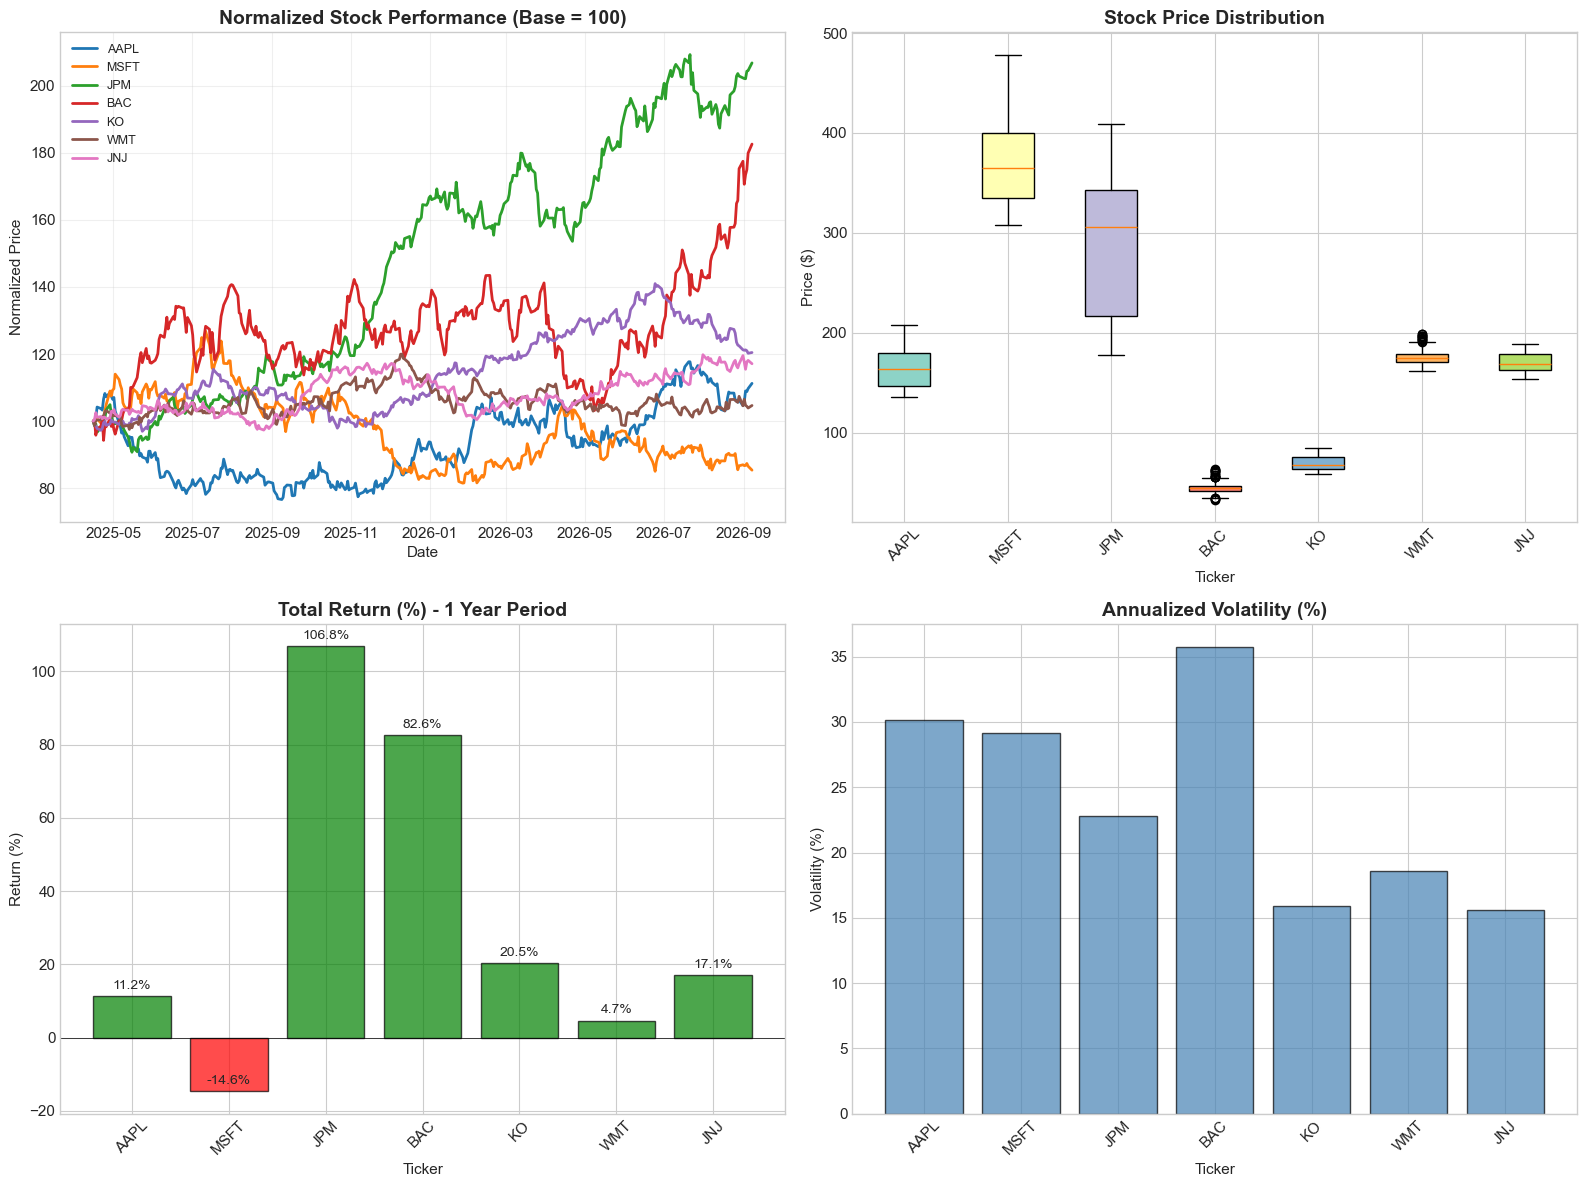

In [17]:
# Plot stock price trends
def plot_price_trends(prices, tickers, daily_rets, save_path=None):
    """
    Plot stock price trends over time.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: All stocks normalized to 100 at start
    ax1 = axes[0, 0]
    normalized = (prices / prices.iloc[0]) * 100
    for ticker in tickers.keys():
        if ticker in prices.columns:
            ax1.plot(normalized.index, normalized[ticker], label=ticker, linewidth=2)
    ax1.set_title('Normalized Stock Performance (Base = 100)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Normalized Price')
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Price distribution (box plot) - using matplotlib to avoid seaborn version issues
    ax2 = axes[0, 1]
    data_list = [prices[col].dropna().values for col in prices.columns]
    bp = ax2.boxplot(data_list, labels=prices.columns, patch_artist=True)
    colors = plt.cm.Set3(range(len(prices.columns)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax2.set_title('Stock Price Distribution', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Ticker')
    ax2.set_ylabel('Price ($)')
    plt.setp(ax2.get_xticklabels(), rotation=45)
    
    # Plot 3: Total returns bar chart
    ax3 = axes[1, 0]
    total_returns = ((prices.iloc[-1] / prices.iloc[0]) - 1) * 100
    colors = ['green' if x > 0 else 'red' for x in total_returns]
    bars = ax3.bar(total_returns.index, total_returns, color=colors, alpha=0.7, edgecolor='black')
    ax3.set_title('Total Return (%) - 1 Year Period', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Ticker')
    ax3.set_ylabel('Return (%)')
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    plt.setp(ax3.get_xticklabels(), rotation=45)
    for bar, value in zip(bars, total_returns):
        height = bar.get_height()
        ax3.annotate(f'{value:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)
    
    # Plot 4: Volatility comparison
    ax4 = axes[1, 1]
    volatility = daily_rets.std() * np.sqrt(252)
    bars = ax4.bar(volatility.index, volatility, color='steelblue', alpha=0.7, edgecolor='black')
    ax4.set_title('Annualized Volatility (%)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Ticker')
    ax4.set_ylabel('Volatility (%)')
    plt.setp(ax4.get_xticklabels(), rotation=45)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()

# Generate price trend plots
plot_price_trends(close_prices, STOCKS, daily_returns, 'figures/price_trends.png')

#### 4.2 Correlation Heatmap

Figure saved to figures/correlation_heatmap.png


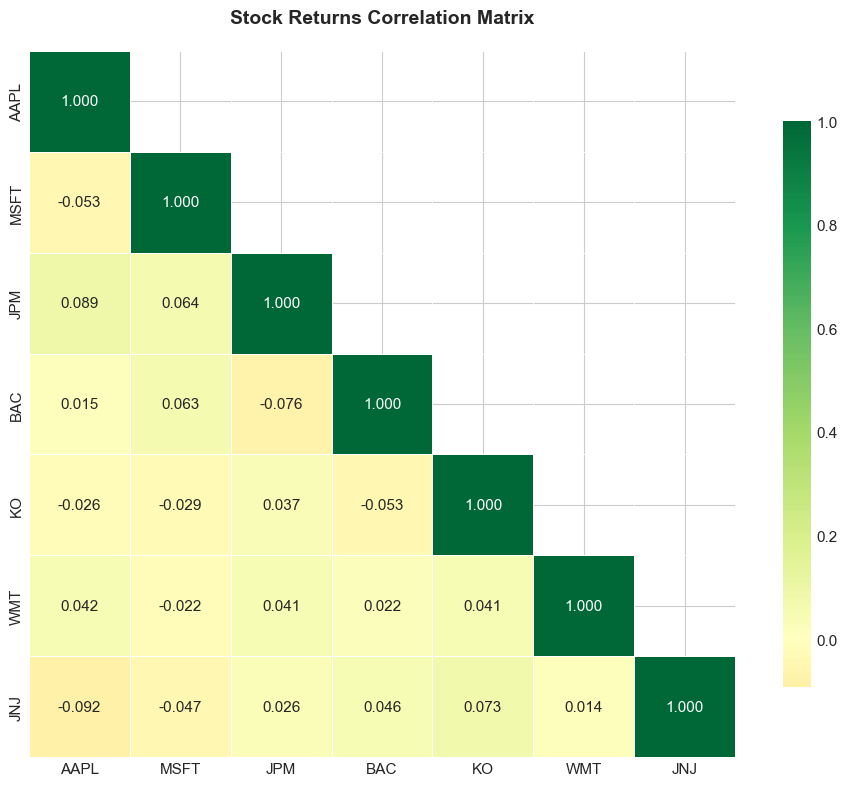

In [18]:
# Plot correlation heatmap
def plot_correlation_heatmap(corr_matrix, save_path=None):
    """
    Plot correlation heatmap of stock returns.
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, 
                mask=mask,
                annot=True, 
                fmt='.3f',
                cmap='RdYlGn',
                center=0,
                square=True,
                linewidths=0.5,
                cbar_kws={'shrink': 0.8},
                ax=ax)
    
    ax.set_title('Stock Returns Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()

# Generate correlation heatmap
plot_correlation_heatmap(correlation_matrix, 'figures/correlation_heatmap.png')

#### 4.3 Risk-Return Analysis

Figure saved to figures/risk_return.png


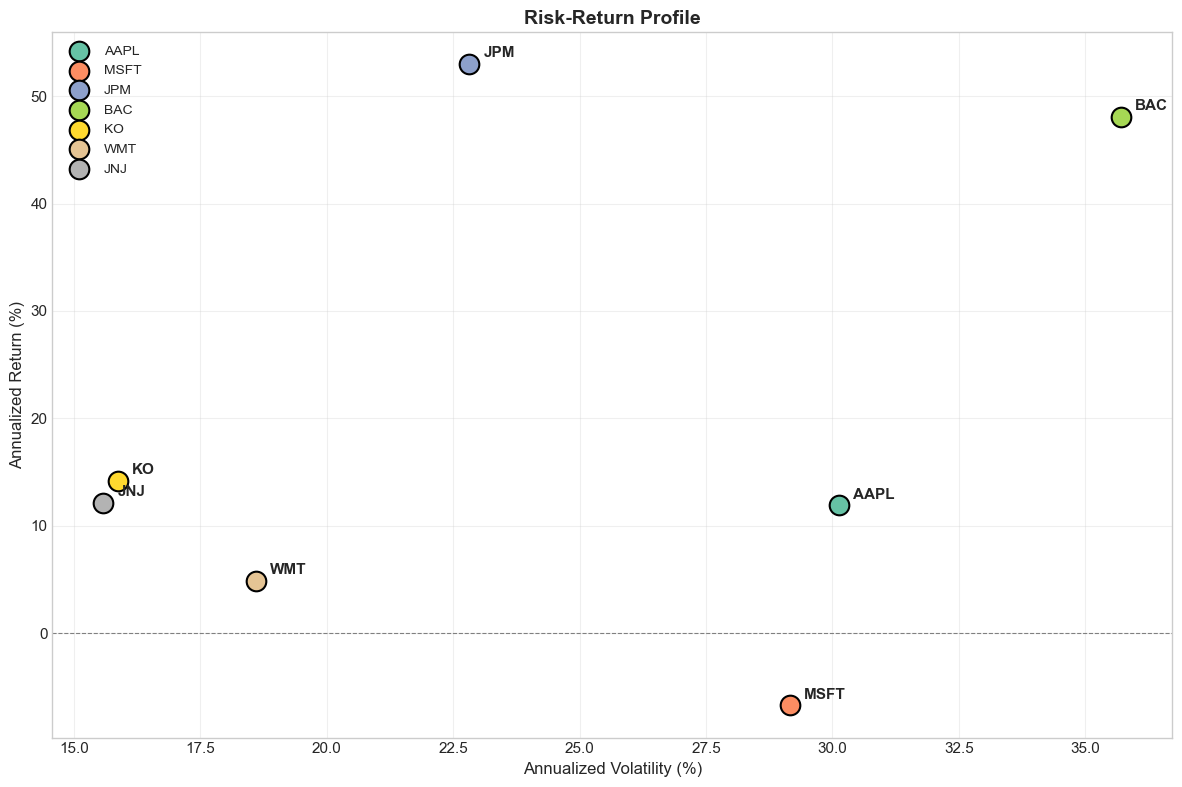

In [19]:
# Plot risk-return scatter
def plot_risk_return(returns, tickers, save_path=None):
    """
    Plot risk-return scatter plot.
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    
    annual_return = returns.mean() * 252
    annual_vol = returns.std() * np.sqrt(252)
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(tickers)))
    
    for i, ticker in enumerate(tickers.keys()):
        if ticker in returns.columns:
            ax.scatter(annual_vol[ticker], annual_return[ticker], 
                       s=200, c=[colors[i]], label=ticker, edgecolors='black', linewidth=1.5)
            ax.annotate(ticker, 
                        (annual_vol[ticker], annual_return[ticker]),
                        xytext=(10, 5), textcoords='offset points',
                        fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Annualized Volatility (%)', fontsize=12)
    ax.set_ylabel('Annualized Return (%)', fontsize=12)
    ax.set_title('Risk-Return Profile', fontsize=14, fontweight='bold')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()

# Generate risk-return plot
plot_risk_return(daily_returns, STOCKS, 'figures/risk_return.png')

#### 4.4 Moving Average Analysis

Figure saved to figures/moving_averages.png


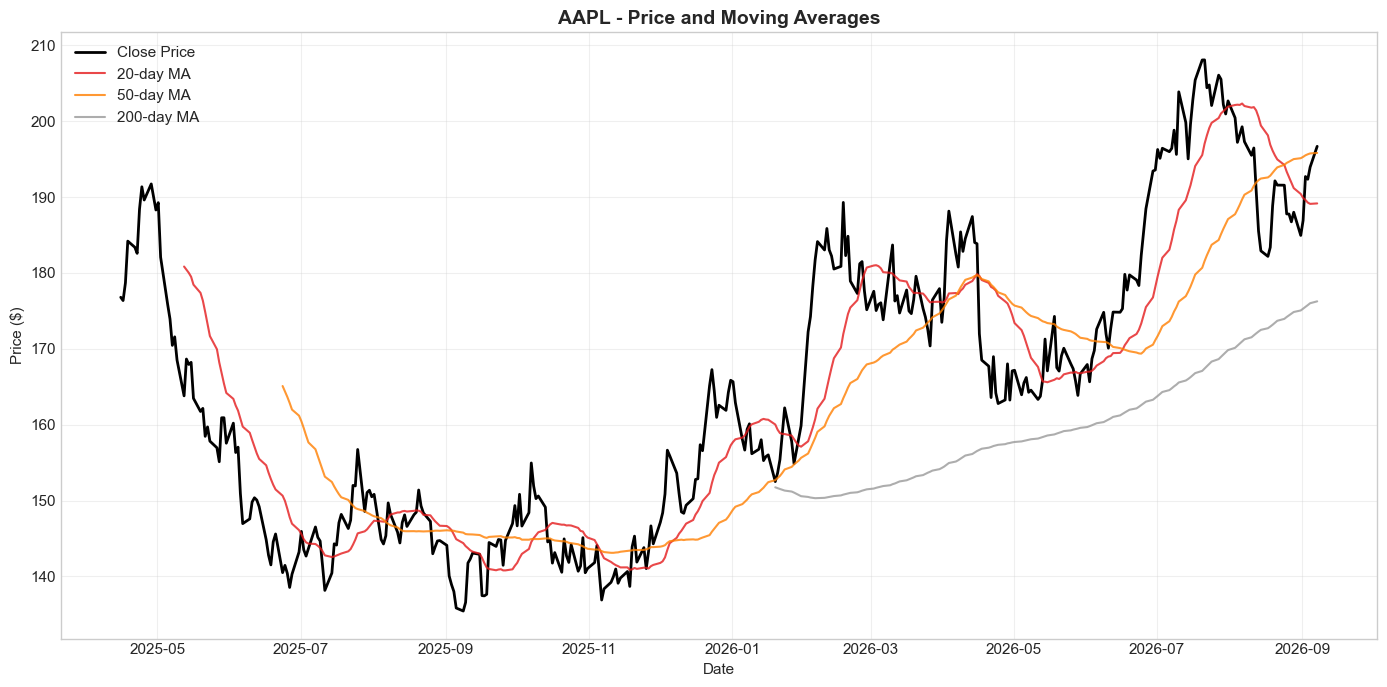

In [20]:
# Calculate and plot moving averages
def plot_moving_averages(prices, ticker, windows=[20, 50, 200], save_path=None):
    """
    Plot stock price with moving averages.
    """
    fig, ax = plt.subplots(figsize=(14, 7))
    
    ax.plot(prices.index, prices[ticker], label='Close Price', linewidth=2, color='black')
    
    colors = plt.cm.Set1(np.linspace(0, 1, len(windows)))
    for window, color in zip(windows, colors):
        if len(prices) >= window:
            ma = prices[ticker].rolling(window=window).mean()
            ax.plot(prices.index, ma, label=f'{window}-day MA', linewidth=1.5, color=color, alpha=0.8)
    
    ax.set_title(f'{ticker} - Price and Moving Averages', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()

# Generate moving average plot for Apple
plot_moving_averages(close_prices, 'AAPL', save_path='figures/moving_averages.png')

### 5. Key Findings and Insights

Based on the analysis, we can derive the following insights:

In [21]:
# Generate summary report
def generate_summary_report(stats_df, risk_df, correlation_matrix):
    """
    Generate a summary report of key findings.
    """
    report = []
    report.append("=" * 60)
    report.append("STOCK PERFORMANCE ANALYSIS - KEY FINDINGS")
    report.append("=" * 60)
    
    if stats_df.empty:
        report.append("\nNo data available for analysis.")
        return "\n".join(report)
    
    # Best and worst performers
    best_return = stats_df['Total Return (%)'].idxmax()
    worst_return = stats_df['Total Return (%)'].idxmin()
    
    report.append(f"\n1. PERFORMANCE HIGHLIGHTS:")
    report.append(f"   - Best Performer: {best_return} ({stats_df.loc[best_return, 'Total Return (%)']:.2f}%)")
    report.append(f"   - Worst Performer: {worst_return} ({stats_df.loc[worst_return, 'Total Return (%)']:.2f}%)")
    
    # Risk analysis
    if not risk_df.empty:
        safest = risk_df['Annual Volatility (%)'].idxmin()
        riskiest = risk_df['Annual Volatility (%)'].idxmax()
        best_sharpe = risk_df['Sharpe Ratio'].idxmax()
        
        report.append(f"\n2. RISK ANALYSIS:")
        report.append(f"   - Lowest Volatility: {safest} ({risk_df.loc[safest, 'Annual Volatility (%)']:.2f}%)")
        report.append(f"   - Highest Volatility: {riskiest} ({risk_df.loc[riskiest, 'Annual Volatility (%)']:.2f}%)")
        report.append(f"   - Best Risk-Adjusted Return: {best_sharpe} (Sharpe: {risk_df.loc[best_sharpe, 'Sharpe Ratio']:.4f})")
    
    # Correlation insights
    if not correlation_matrix.empty and correlation_matrix.shape[0] >= 2:
        corr_values = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
        max_corr = corr_values.max().max()
        max_corr_pair = corr_values.stack().idxmax()
        min_corr = corr_values.min().min()
        min_corr_pair = corr_values.stack().idxmin()
        
        report.append(f"\n3. CORRELATION INSIGHTS:")
        report.append(f"   - Highest Correlation: {max_corr_pair[0]} & {max_corr_pair[1]} ({max_corr:.4f})")
        report.append(f"   - Lowest Correlation: {min_corr_pair[0]} & {min_corr_pair[1]} ({min_corr:.4f})")
    
    report.append("\n" + "=" * 60)
    
    return "\n".join(report)

# Generate and display summary
summary = generate_summary_report(stats_df, risk_df, correlation_matrix)
print(summary)

STOCK PERFORMANCE ANALYSIS - KEY FINDINGS

1. PERFORMANCE HIGHLIGHTS:
   - Best Performer: JPM (106.82%)
   - Worst Performer: MSFT (-14.63%)

2. RISK ANALYSIS:
   - Lowest Volatility: JNJ (15.58%)
   - Highest Volatility: BAC (35.72%)
   - Best Risk-Adjusted Return: JPM (Sharpe: 2.1013)

3. CORRELATION INSIGHTS:
   - Highest Correlation: AAPL & JPM (0.0886)
   - Lowest Correlation: AAPL & JNJ (-0.0917)



### 6. Save Analysis Results

In [22]:
# Save all analysis results to CSV files
stats_df.to_csv('data/stock_statistics.csv')
risk_df.to_csv('data/stock_risk_metrics.csv')
correlation_matrix.to_csv('data/correlation_matrix.csv')

print("All analysis results saved successfully!")
print("\nFiles created:")
print("- data/sample_stock_prices.csv (offline backup for app.py)")
print("- data/stock_statistics.csv")
print("- data/stock_risk_metrics.csv")
print("- data/correlation_matrix.csv")
print("- figures/price_trends.png")
print("- figures/correlation_heatmap.png")
print("- figures/risk_return.png")
print("- figures/moving_averages.png")

All analysis results saved successfully!

Files created:
- data/sample_stock_prices.csv (offline backup for app.py)
- data/stock_statistics.csv
- data/stock_risk_metrics.csv
- data/correlation_matrix.csv
- figures/price_trends.png
- figures/correlation_heatmap.png
- figures/risk_return.png
- figures/moving_averages.png


### 7. Conclusion

This notebook demonstrates a comprehensive stock performance analysis workflow:

1. **Data Acquisition**: Successfully downloaded historical stock data from Yahoo Finance
2. **Data Cleaning**: Handled missing values using forward fill and backward fill, prepared clean dataset
3. **Statistical Analysis**: Calculated key metrics including returns, volatility, and Sharpe ratios
4. **Visualization**: Created informative charts showing price trends, correlations, and risk-return profiles
5. **Insights**: Identified best/worst performers, risk characteristics, and correlation patterns

**For interactive exploration, please run the Streamlit app (`app.py`).**

---
**Note:** The file `data/sample_stock_prices.csv` saved by this notebook is automatically used by `app.py` as an offline backup when the Yahoo Finance API is rate-limited.